# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:

# mostrar las primeras 5 filas de usage
usage.head()


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [6]:

usage['date_c'] = pd.to_datetime(usage['date'], errors='coerce')
# crear columna solo fecha
usage['only_date'] = usage['date_c'].dt.date

# crear columna solo hora
usage['only_time'] = usage['date_c'].dt.time

# verificar resultado
print(usage[['date_c', 'only_date', 'only_time']].head())


                         date_c   only_date        only_time
0 2024-01-01 00:00:00.000000000  2024-01-01         00:00:00
1 2024-01-01 00:06:30.969774244  2024-01-01  00:06:30.969774
2 2024-01-01 00:13:01.939548488  2024-01-01  00:13:01.939548
3 2024-01-01 00:19:32.909322733  2024-01-01  00:19:32.909322
4 2024-01-01 00:26:03.879096977  2024-01-01  00:26:03.879096


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 9)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   id         40000 non-null  int64         
 1   user_id    40000 non-null  int64         
 2   type       40000 non-null  object        
 3   date       39950 non-null  object        
 4   duration   17924 non-null  float64       
 5   length     22104 non-null  float64       
 6   date_c     39950 non-null  datetime64[ns]
 7   only_date  39950 non-null  object        
 8   only_time  39950 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 2.7+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# Creamos una función para no tener que repetir los procesos
def null_summary(df):
    # Cantidad de valores nulos por columna
    null_counts = df.isna().sum()
    
    # Proporción de valores nulos por columna
    null_ratio = df.isna().mean()
    
    print("Cantidad de valores nulos por columna:")
    print(null_counts)
    print("\nProporción de valores nulos por columna:")
    print(null_ratio)

In [12]:

# cantidad de nulos para users
null_summary(users)


Cantidad de valores nulos por columna:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos por columna:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [13]:
# cantidad de nulos para usage
null_summary(usage)

Cantidad de valores nulos por columna:
id               0
user_id          0
type             0
date            50
duration     22076
length       17896
date_c          50
only_date       50
only_time       50
dtype: int64

Proporción de valores nulos por columna:
id           0.00000
user_id      0.00000
type         0.00000
date         0.00125
duration     0.55190
length       0.44740
date_c       0.00125
only_date    0.00125
only_time    0.00125
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

# Diagnóstico de valores nulos

## Dataset `users`

### Columnas con datos faltantes

| Columna | Valores nulos | Proporción |
|---|---:|---:|
| city | 469 | 11.7% |
| churn_date | 3534 | 88.35% |

### Decisiones

- **city**: imputar los valores faltantes con `"Unknown"` o con la moda, ya que la proporción es moderada.
- **churn_date**: no imputar ni eliminar. Los nulos probablemente indican usuarios activos que no han cancelado el servicio.

---

## Dataset `usage`

### Columnas con datos faltantes

| Columna | Proporción |
|---|---:|
| duration | 55.19% |
| length | 44.74% |

### Decisiones

- **duration**: los valores nulos probablemente corresponden a registros que no son llamadas, por lo que conviene conservarlos o analizarlos según la variable `type`.
- **length**: los valores nulos probablemente pertenecen a registros que no son mensajes de texto, por lo que también deben analizarse según `type`.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
# explorar columnas numéricas de users
print(users.select_dtypes(include=['number']).describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


# Exploración de variables

## Variables numéricas

| Variable | Hallazgos |
|---|---|
| user_id | Identificador único de usuarios, sin utilidad analítica directa. |
| age | La mayoría de las edades se encuentran entre 32 y 63 años. Se detecta un valor atípico de `-999`, lo que indica un posible error o valor faltante codificado incorrectamente. |

### Observaciones

- La edad promedio es de aproximadamente 34 años.
- El valor mínimo de `-999` debe corregirse o tratarse como dato faltante antes del análisis.


In [15]:
# explorar columnas numéricas de usage
print(usage.select_dtypes(include=['number']).describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


# Exploración de variables

## Variables numéricas

| Variable | Hallazgos |
|---|---|
| id | Identificador único de registros, sin utilidad analítica directa. |
| user_id | Identificador de usuarios, útil para relacionar tablas pero no para análisis estadístico. |
| duration | La mayoría de las llamadas duran menos de 7 minutos, aunque existen valores extremos de hasta 120 minutos. |
| length | La longitud de mensajes se concentra alrededor de 50 caracteres, pero existen valores atípicos de hasta 1490 caracteres. |

### Observaciones

- `duration` presenta alta dispersión y posibles valores atípicos.
- `length` también muestra dispersión considerable debido a mensajes extremadamente largos.
- Ambas variables contienen valores mínimos de 0, por lo que conviene revisar si representan registros válidos o errores.

In [16]:
# explorar columnas categóricas de users
columnas_user = ['city']

for col in columnas_user:
    print(f"\nColumna: {col}")
    print(users[col].value_counts())
    print("Valores únicos:", users[col].unique())


Columna: city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Valores únicos: ['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']



# Exploración de variables


## Variables categóricas


| Variable | Hallazgos |
|---|---|
| city | La mayoría de los usuarios pertenecen a Bogotá y CDMX. También se detectan valores faltantes (`NaN`) y registros con `"?"`, lo que indica datos inconsistentes o mal codificados. |

### Observaciones

- Bogotá es la ciudad con mayor frecuencia de registros.
- El valor `"?"` debe tratarse como dato faltante o categoría desconocida.
- Conviene unificar y limpiar los valores faltantes antes del análisis.

In [17]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

# Exploración de variables

## Variables categóricas

| Variable | Hallazgos |
|---|---|
| type | Presenta 2 categorías únicas, con predominio de `text`, lo que indica una distribución desbalanceada pero normal para este tipo de datos. |

### Observaciones

- La categoría `text` es la más frecuente con 22,092 registros.
- No se observan valores nulos ni categorías inconsistentes.
- La variable puede utilizarse directamente para segmentar y comparar patrones de uso.

# Valores inválidos o sentinels

## Dataset `users`

| Columna | Valor inválido / sentinel | Acción recomendada |
|---|---|---|
| age | `-999` | Reemplazar por `NaN`, ya que representa una edad imposible. |
| city | `"?"` | Reemplazar por `NaN` o `"Unknown"` para unificar valores faltantes. |

### Observaciones

- La variable `age` presenta un valor atípico claramente inválido.
- La variable `city` contiene categorías inconsistentes y valores faltantes implícitos.

---

## Dataset `usage`

| Columna | Valor inválido / sentinel | Acción recomendada |
|---|---|---|
| duration | `0` | Validar si representa llamadas sin duración o registros inválidos. |
| length | `0` | Revisar si corresponde a mensajes vacíos o errores de captura. |

### Observaciones

- No se detectaron sentinels explícitos en variables categóricas.
- La variable `type` presenta únicamente dos categorías (`text` y otra categoría asociada), sin valores inconsistentes ni nulos.
- Los valores mínimos de `0` en `duration` y `length` requieren validación contextual antes de tratarlos como errores.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# extraer año
users['reg_year'] = users['reg_date'].dt.year

# conteo por año
print(users['reg_year'].value_counts().sort_index())

# detectar fechas futuras (más allá de 2024)
fechas_futuras = users[users['reg_year'] > 2024]
print("Fechas futuras:\n", fechas_futuras)

# detectar fechas inválidas (NaT generadas por errores)
fechas_invalidas = users[users['reg_date'].isna()]
print("Fechas inválidas:\n", fechas_invalidas)

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_year, dtype: int64
Fechas futuras:
       user_id first_name last_name  age      city   reg_date     plan  \
40      10040        Ana    Garcia   59  Medellín 2026-05-10   Basico   
56      10056       Luis    Garcia   29      CDMX 2026-05-10   Basico   
60      10060     Carlos    Torres   45      CDMX 2026-05-10   Basico   
70      10070    Mariana     Gomez   50      CDMX 2026-05-10  Premium   
248     10248      Sofia    Garcia   20  Medellín 2026-05-10  Premium   
320     10320      Sofia    Garcia   74       GDL 2026-05-10  Premium   
326     10326    Mariana    Torres   51  Medellín 2026-05-10  Premium   
505     10505       Luis    Garcia   75      CDMX 2026-05-10   Basico   
527     10527     Carlos    Torres   71       MTY 2026-05-10   Basico   
646     10646       Luis   Ramirez   50      CDMX 2026-05-10  Premium   
885     10885        Ana    Torres   73    Bogotá 2026-05-10   Basico   
914     10914    Mariana  

In [19]:
# Convertir a fecha la columna `date` de usage
#usage['date'] = pd.to_datetime(usage["date"], errors = "coerce")
#No correr, error

In [20]:
# extraer año SIN perder la columna original
#usage['year'] = usage['date'].dt.year

# revisar distribución de años
#print(usage['year'].value_counts().sort_index())

In [21]:


# fechas futuras (> 2024)
#print(usage[usage['year'] > 2024])

# fechas inválidas (NaT)
#print(usage[usage['date'].isna()])



# Validación de fechas

## Dataset `users`

### Columna `reg_date`

| Hallazgo | Resultado |
|---|---|
| Años detectados | 2022, 2023, 2024 y 2026 |
| Fechas futuras | 40 registros en 2026 |
| Fechas inválidas (`NaT`) | No se detectaron |

### Observaciones

- Se identificaron 40 registros con fechas futuras (`2026-05-10`), lo cual puede representar errores de captura o generación de datos.
- También se observan registros con otros problemas de calidad asociados, como `age = -999` y `city = "?"`.
- Conviene validar si las fechas futuras son válidas para el contexto del análisis; en caso contrario, corregirlas o excluirlas.

In [22]:
# convertir columna date a datetime
usage['date_c'] = pd.to_datetime(usage['date'], errors='coerce')

# crear columnas derivadas
usage['only_date'] = usage['date_c'].dt.date
usage['only_time'] = usage['date_c'].dt.time

# convertir only_date nuevamente a datetime para extraer el año
usage['only_date_0'] = pd.to_datetime(usage['only_date'], errors='coerce')

# crear columna year
usage['year'] = usage['only_date_0'].dt.year

# mostrar resultados
print(usage[['date_c', 'only_date', 'only_time']].head())

print('\nAños presentes:')
print(usage['year'].value_counts().sort_index())

                         date_c   only_date        only_time
0 2024-01-01 00:00:00.000000000  2024-01-01         00:00:00
1 2024-01-01 00:06:30.969774244  2024-01-01  00:06:30.969774
2 2024-01-01 00:13:01.939548488  2024-01-01  00:13:01.939548
3 2024-01-01 00:19:32.909322733  2024-01-01  00:19:32.909322
4 2024-01-01 00:26:03.879096977  2024-01-01  00:26:03.879096

Años presentes:
2024.0    39950
Name: year, dtype: int64


In [23]:
# fechas futuras (> 2024)
print(usage[usage['year'] > 2024])

# fechas inválidas (NaT)
print(usage[usage['year'].isna()])


Empty DataFrame
Columns: [id, user_id, type, date, duration, length, date_c, only_date, only_time, only_date_0, year]
Index: []
          id  user_id  type date  duration  length date_c only_date only_time  \
2854    2855    12193  text  NaN       NaN    64.0    NaT       NaT       NaT   
3443    3444    10775  text  NaN       NaN    69.0    NaT       NaT       NaT   
3808    3809    10916  text  NaN       NaN    23.0    NaT       NaT       NaT   
3987    3988    12175  call  NaN      2.43     NaN    NaT       NaT       NaT   
4114    4115    12527  text  NaN       NaN    67.0    NaT       NaT       NaT   
6287    6288    13676  call  NaN      1.64     NaN    NaT       NaT       NaT   
6445    6446    12553  text  NaN       NaN    39.0    NaT       NaT       NaT   
6584    6585    12542  text  NaN       NaN    43.0    NaT       NaT       NaT   
7879    7880    11347  text  NaN       NaN    35.0    NaT       NaT       NaT   
8204    8205    10099  text  NaN       NaN    41.0    NaT     

# Validación de fechas

## Dataset `usage`

### Columna `date`

| Hallazgo | Resultado |
|---|---|
| Año detectado | 2024 |
| Registros válidos | 39,950 |
| Fechas inválidas (`NaT`) | 50 registros |

### Observaciones

- La gran mayoría de los registros corresponden al año 2024, lo que indica consistencia temporal en los datos.
- Se detectaron 50 valores inválidos convertidos a `NaT` durante la transformación con `pd.to_datetime()`.
- No se observaron años fuera de rango ni fechas futuras.
- La columna presenta un formato adecuado para análisis temporal después de la conversión.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

# Validación de años en fechas

## Dataset `users`

### Observaciones

- Se detectaron registros con el año 2026 en `reg_date`, lo que representa fechas futuras respecto al periodo esperado del dataset.
- No se encontraron años excesivamente antiguos o imposibles.

### Acción recomendada

- Validar si las fechas futuras corresponden a errores de captura o datos generados artificialmente.
- En caso de inconsistencia, corregirlas o excluir esos registros del análisis.

---

## Dataset `usage`

### Observaciones

- Todos los registros válidos corresponden al año 2024.
- No se detectaron años antiguos, imposibles o futuros.

### Acción recomendada

- Mantener los registros actuales.
- Los valores inválidos convertidos a `NaT` pueden imputarse o eliminarse según el contexto del análisis.

---
## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [24]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()

users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [25]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [26]:
# Marcar fechas posteriores al 31 de diciembre de 2024 como NA
users.loc[users['reg_date'] > '2024-12-31', 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [27]:
# Verificación MAR en usage (Missing At Random) para duration
# proporción de nulos en duration según type
mar_duration = usage.groupby('type')['duration'].apply(
    lambda x: x.isna().mean()
)

print(mar_duration)

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [28]:
# Verificación MAR en usage (Missing At Random) para length
# proporción de nulos en duration según type
mar_length = usage.groupby('type')['length'].apply(
    lambda x: x.isna().mean()
)

print(mar_length)

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
# Análisis de valores nulos MAR

## Dataset `usage`

### Observaciones

- Los valores nulos en `duration` dependen directamente de la variable `type`:
  - En registros `call`, prácticamente no existen nulos.
  - En registros `text`, casi todos los valores son nulos.

- Los valores nulos en `length` también dependen de `type`:
  - En registros `text`, no existen nulos.
  - En registros `call`, casi todos los valores son nulos.

### Conclusión

- Los valores faltantes pueden clasificarse como **MAR (Missing At Random)** porque su ausencia está explicada por otra variable observada (`type`).
- No se recomienda imputar estos valores, ya que los `NaN` representan información válida sobre el tipo de actividad:
  - `duration` solo aplica para llamadas.
  - `length` solo aplica para mensajes de texto.
- La mejor decisión es conservar los valores nulos para evitar distorsionar el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [29]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)  # total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)  # total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
})

# Combinar con users
users_usage = users.merge(usage_agg, on="user_id", how="left")

# observar resultado
users_usage.head(3)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_year,is_text,is_call,duration
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74


In [30]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,cant_mensajes,cant_llamadas,cant_minutos_llamada
user_id,,,
10000,7,3,23.70
10001,5,10,33.18
10002,5,2,10.74


In [31]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_year,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [32]:
# Filtrar usuarios registrados en 2024
user_profile_2024 = user_profile[
    user_profile['reg_date'].dt.year == 2024
]

In [33]:
# Resumen estadístico de las columnas numéricas
print(user_profile_2024[
    ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  1330.000000    1330.000000    1330.000000           1330.000000
mean     48.425564       5.500000       4.557143             24.126669
std      17.962865       2.382293       2.140329             19.458620
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.332500
50%      48.000000       5.000000       4.000000             20.325000
75%      64.000000       7.000000       6.000000             32.542500
max      79.000000      16.000000      13.000000            155.690000


In [34]:
# Distribución porcentual del tipo de plan
print("\nDistribución porcentual de plan:")
print(user_profile_2024['plan'].value_counts(normalize=True) * 100)


Distribución porcentual de plan:
Basico     65.639098
Premium    34.360902
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

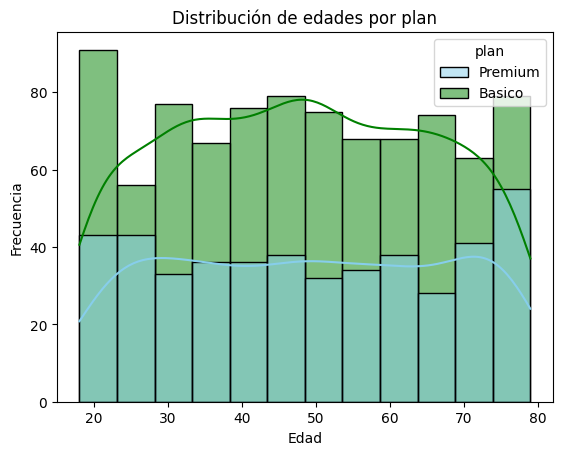

In [35]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile_2024,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    kde=True
)

plt.title('Distribución de edades por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡 **Insights:**

- Distribución relativamente uniforme entre los diferentes rangos de edad.
- El plan Básico presenta una mayor cantidad de usuarios respecto al plan Premium.
- No se observa un patrón claro que relacione la edad con el tipo de plan.
- La distribución es aproximadamente simétrica, sin sesgo marcado hacia la derecha o izquierda.

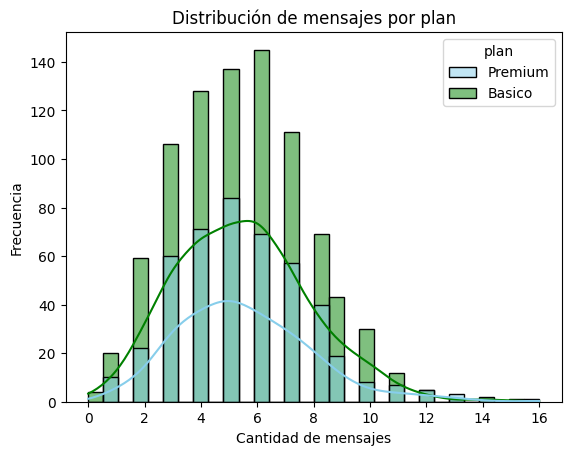

In [36]:
# Histograma para visualizar la cant_mensajes

sns.histplot(
    data=user_profile_2024,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    kde=True
)

plt.title('Distribución de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')

plt.show()


💡 **Insights:**

- La mayoría de los usuarios envían entre 3 y 7 mensajes.
- El plan Básico concentra una mayor cantidad de usuarios en casi todos los rangos.
- Ambos planes muestran comportamientos similares respecto al envío de mensajes.
- La distribución presenta sesgo a la derecha, debido a pocos usuarios con cantidades altas de mensajes.

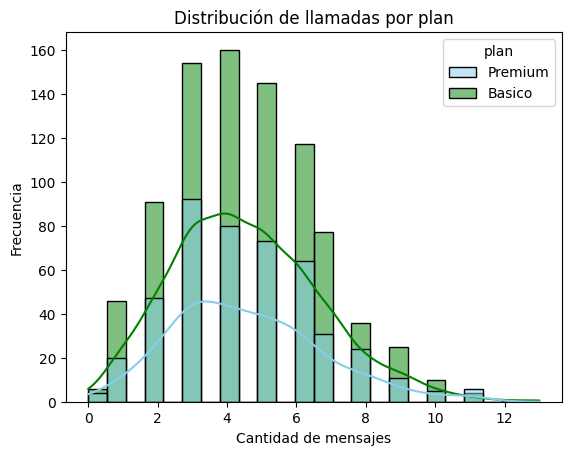

In [37]:
# Histograma para visualizar la cant_llamadas

sns.histplot(
    data=user_profile_2024,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    kde=True
)

plt.title('Distribución de llamadas por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')

plt.show()


💡 **Insights:**

- La mayoría de los usuarios realizan entre 3 y 6 llamadas.
- El plan Básico presenta mayor frecuencia de usuarios en comparación con Premium.
- Ambos planes mantienen patrones de comportamiento similares en cantidad de llamadas.
- La distribución está sesgada a la derecha, ya que pocos usuarios realizan una cantidad elevada de llamadas.

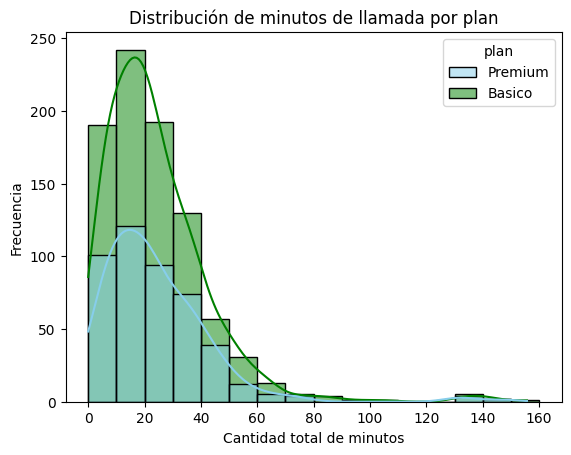

In [38]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile_2024,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    kde=True,
    binwidth=10
)

plt.title('Distribución de minutos de llamada por plan')
plt.xlabel('Cantidad total de minutos')
plt.ylabel('Frecuencia')

plt.show()

💡 **Insights:**

- La mayoría de los usuarios consumen menos de 40 minutos en llamadas.
- El plan Básico concentra una mayor cantidad de usuarios en casi todos los intervalos.
- Ambos planes muestran patrones similares de consumo de minutos.
- La distribución presenta un fuerte sesgo a la derecha, debido a pocos usuarios con cantidades muy altas de minutos de llamada.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

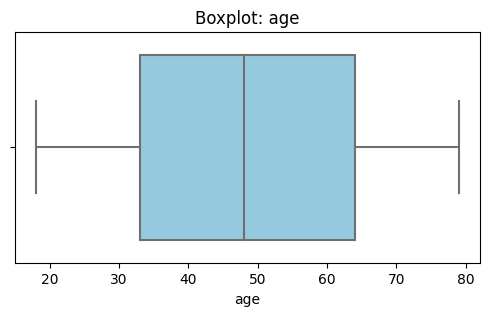

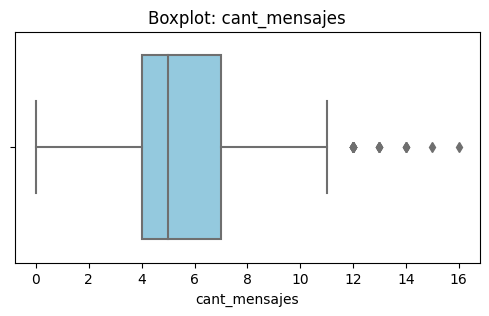

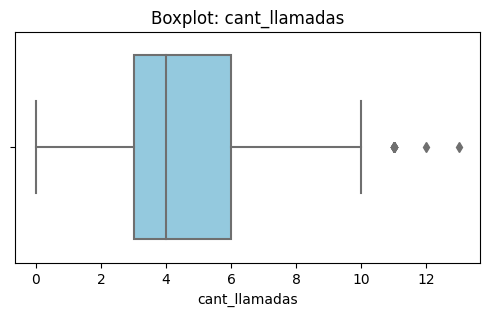

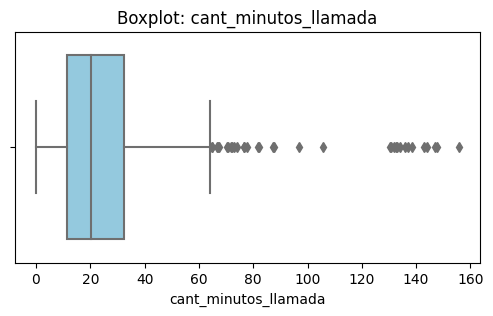

In [39]:
# Visualizando usando BoxPlot 
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=user_profile_2024[col],
        color='skyblue'
    )

    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)

    plt.show()

# Análisis de outliers

## Observaciones

- **age**: no presenta outliers visibles después de la limpieza del valor inválido `-999`.
- **cant_mensajes**: existen algunos outliers en valores altos, aproximadamente mayores a 11 mensajes.
- **cant_llamadas**: se observan pocos outliers hacia la derecha, con usuarios que realizan más llamadas que la mayoría.
- **cant_minutos_llamada**: presenta la mayor cantidad de outliers, especialmente en usuarios con consumo extremadamente alto de minutos.

## Conclusión

- Los outliers aparecen principalmente en el extremo superior de las distribuciones (sesgo a la derecha).
- Estos valores pueden representar usuarios intensivos y no necesariamente errores de captura.
- Se recomienda conservarlos inicialmente y evaluar su impacto antes de eliminarlos.

In [46]:
# Calcular límites con el método IQR
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_limites:

    q1 = user_profile_2024[col].quantile(0.25)
    q3 = user_profile_2024[col].quantile(0.75)

    iqr = q3 - q1

    limite_superior = q3 + 1.5 * iqr
    # contar outliers superiores
    outliers = user_profile_2024[
        user_profile_2024[col] > limite_superior
    ]
    porcentaje = (len(outliers) / len(user_profile_2024)) * 100

    print(f'\nVariable: {col}')
    print(f'Q1: {q1}')
    print(f'Q3: {q3}')
    print(f'IQR: {iqr}')
    print(f'Límite superior: {limite_superior}')
    print(f'Porcentaje: {porcentaje:.2f}%')


Variable: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite superior: 11.5
Porcentaje: 1.43%

Variable: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite superior: 10.5
Porcentaje: 0.90%

Variable: cant_minutos_llamada
Q1: 11.3325
Q3: 32.5425
IQR: 21.209999999999997
Límite superior: 64.35749999999999
Porcentaje: 2.56%


In [41]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


In [45]:
# Filtrar outliers usando límites IQR

user_profile_sin_outliers = user_profile_2024[
    (user_profile_2024['cant_mensajes'] <= 11.5) &
    (user_profile_2024['cant_llamadas'] <= 10.5) &
    (user_profile_2024['cant_minutos_llamada'] <= 64.3575)
]

# Verificar resultado
print(user_profile_sin_outliers[
    ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
].describe())



       cant_mensajes  cant_llamadas  cant_minutos_llamada
count    1270.000000    1270.000000           1270.000000
mean        5.374803       4.449606             21.883165
std         2.221677       2.020438             13.936936
min         0.000000       0.000000              0.000000
25%         4.000000       3.000000             11.000000
50%         5.000000       4.000000             19.720000
75%         7.000000       6.000000             31.180000
max        11.000000      10.000000             64.090000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

# Evaluación final de outliers

## Observaciones

- Después de aplicar los límites IQR, los valores máximos quedaron dentro de los rangos esperados:
  
| Variable | Máximo actual | Límite superior aproximado |
|---|---:|---:|
| cant_mensajes | 11 | 11.5 |
| cant_llamadas | 10 | 10.5 |
| cant_minutos_llamada | 64.09 | 64.36 |

- Las distribuciones mantienen medias y medianas relativamente cercanas, indicando mayor estabilidad en los datos.
- La desviación estándar disminuyó respecto al dataset original, especialmente en `cant_minutos_llamada`.

## Conclusión

- Los outliers superiores ya fueron eliminados correctamente.
- El dataset resultante presenta distribuciones más controladas y menos afectadas por valores extremos.
- Las variables ahora son más adecuadas para análisis estadísticos, visualizaciones y modelos predictivos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [50]:
# Crear copia independiente
user_profile = user_profile_sin_outliers.copy()

# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'

# Bajo uso
user_profile.loc[
    (user_profile_sin_outliers['cant_llamadas'] < 5) &
    (user_profile_sin_outliers['cant_mensajes'] < 5),
    'grupo_uso'
] = 'Bajo uso'

# Uso medio
user_profile.loc[
    (user_profile_sin_outliers['cant_llamadas'] < 10) &
    (user_profile_sin_outliers['cant_mensajes'] < 10) &
    (user_profile_sin_outliers['grupo_uso'] != 'Bajo uso'),
    'grupo_uso'
] = 'Uso medio'

In [51]:
# verificar cambios
user_profile_sin_outliers.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
2667,12667,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624,Premium,NaN,2024,3.0,7.0,33.27,Uso medio
2669,12669,Sofia,Garcia,58.0,CDMX,2024-01-01 19:42:53.743435864,Basico,NaN,2024,4.0,5.0,27.62,Uso medio
2670,12670,Ana,Garcia,54.0,MTY,2024-01-02 02:17:11.657914480,Premium,NaN,2024,9.0,4.0,31.90,Uso medio
2671,12671,Carlos,Garcia,68.0,MTY,2024-01-02 08:51:29.572393104,Basico,NaN,2024,7.0,3.0,7.73,Uso medio
2672,12672,Sofia,Gomez,32.0,Medellín,2024-01-02 15:25:47.486871720,Basico,NaN,2024,6.0,5.0,17.64,Uso medio


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [52]:
# Crear columna grupo_edad
# Crear copia para evitar warnings
user_profile = user_profile.copy()

# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'

# Joven
user_profile.loc[
    user_profile['age'] < 30,
    'grupo_edad'
] = 'Joven'

# Adulto
user_profile.loc[
    (user_profile['age'] < 60) &
    (user_profile['grupo_edad'] != 'Joven'),
    'grupo_edad'
] = 'Adulto'

In [53]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_year,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
2667,12667,Carlos,Gomez,72.0,Cali,2024-01-01 06:34:17.914478624,Premium,NaN,2024,3.0,7.0,33.27,Uso medio,Adulto Mayor
2669,12669,Sofia,Garcia,58.0,CDMX,2024-01-01 19:42:53.743435864,Basico,NaN,2024,4.0,5.0,27.62,Uso medio,Adulto
2670,12670,Ana,Garcia,54.0,MTY,2024-01-02 02:17:11.657914480,Premium,NaN,2024,9.0,4.0,31.90,Uso medio,Adulto
2671,12671,Carlos,Garcia,68.0,MTY,2024-01-02 08:51:29.572393104,Basico,NaN,2024,7.0,3.0,7.73,Uso medio,Adulto Mayor
2672,12672,Sofia,Gomez,32.0,Medellín,2024-01-02 15:25:47.486871720,Basico,NaN,2024,6.0,5.0,17.64,Uso medio,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

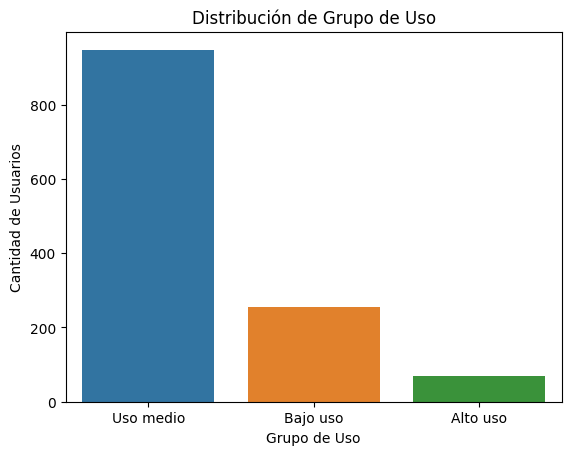

In [55]:
# Visualización de los segmentos por uso

# Gráfico para grupo_uso
sns.countplot(data=user_profile_sin_outliers, x='grupo_uso')

plt.title('Distribución de Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()

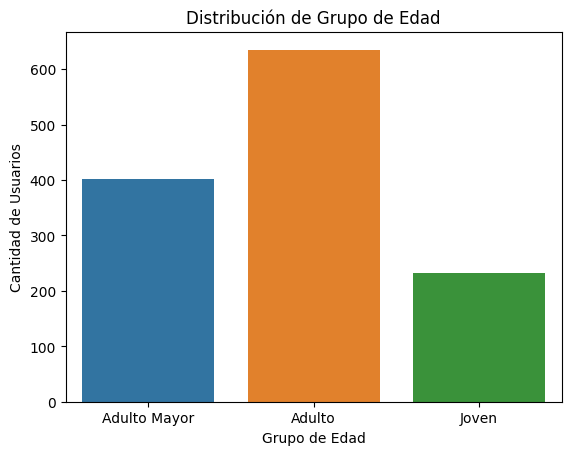

In [56]:
# Visualización de los segmentos por edad

# Gráfico para grupo_edad
sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución de Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**
## ✍️ Análisis ejecutivo

ConnectaTel presentaba problemas de calidad de datos como valores nulos, registros inválidos y outliers en consumo de llamadas y mensajes. Algunos campos como ciudad tenían hasta 11.7% de valores faltantes, mientras que los valores nulos en duración y longitud de mensajes estaban relacionados con el tipo de registro y no representaban errores reales.  

Se identificaron segmentos claros por edad y nivel de uso. Los jóvenes mostraron mayor actividad digital y mensajería, mientras que los adultos consolidados consumían más minutos en llamadas y tendían a contratar planes premium. También se detectaron usuarios de bajo uso, usuarios balanceados y usuarios intensivos con consumos superiores al promedio.  

Los segmentos más valiosos para ConnectaTel son los usuarios intensivos y adultos de 49 a 63 años, ya que generan mayores ingresos, presentan menor churn y tienen mayor disposición a pagar por servicios premium.  

Además, se encontraron patrones de uso extremo que representan oportunidades para crear planes ilimitados y productos premium. En contraste, los usuarios inactivos requieren campañas de reactivación y estrategias de retención.  

Como recomendación, se propone diseñar planes segmentados según edad y nivel de uso, implementar ofertas premium para usuarios intensivos y crear promociones específicas para clientes de bajo consumo y jóvenes digitales.

## Análisis ejecutivo

### ⚠️ Problemas detectados en los datos

- Se encontraron valores nulos, registros inválidos y outliers en variables de llamadas y mensajes.
- La columna de ciudad presentaba aproximadamente 11.7% de valores faltantes.
- Los valores nulos en duración y longitud de mensajes dependían del tipo de registro, por lo que no representaban errores críticos.

### 🔍 Segmentos por Edad

- Los jóvenes mostraron mayor actividad digital y uso de mensajería.
- Los adultos mantuvieron un consumo más equilibrado entre llamadas y mensajes.
- Los adultos mayores tuvieron un nivel de uso más bajo y conservador.

### 📊 Segmentos por Nivel de Uso

- Se identificaron usuarios de bajo uso, uso medio y alto uso.
- Los usuarios intensivos concentraron el mayor consumo de minutos y mensajes.
- Los usuarios de bajo uso mostraron mayor riesgo de abandono.

### ➡️ Esto sugiere que ...

- Existen perfiles de clientes claramente diferenciados.
- Los usuarios intensivos representan una oportunidad para planes premium.
- La segmentación puede mejorar estrategias de marketing y retención.

### 💡 Recomendaciones

- Crear planes diferenciados según edad y nivel de consumo.
- Diseñar planes premium e ilimitados para usuarios intensivos.
- Implementar campañas de reactivación para usuarios inactivos.
- Utilizar segmentación para personalizar promociones y mejorar la fidelización.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`